# Lab 5: Hyperspectral and Sentinel-2 Water Quality Analysis

This notebook follows the TODO for Lab 5.

## Objectives:
- Display false-color composites from the airborne hyperspectral data cube
- Calculate water quality indices (Chl-a, DOC, turbidity) from airborne data
- Download Sentinel-2 data close to the airborne acquisition date
- Calculate the same indices for Sentinel-2 and compare results
- Prepare SAM using the Lab 3 spectral library and consider calibration with airborne data

## Data Overview
- **Airborne data**: ENVI/BSQ format in `data/images/` (hyperspectral cube)
- **Viewer tool**: `viewer.py` enables RGB preview and pixel spectrum export
- **Spectral library**: Reference from Lab 3 (water, green areas, forest)

## Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Remote sensing libraries
try:
    import spectral.io.envi as envi
except ImportError:
    print("spectral library not found. Install with: pip install spectral")

# Configuration
DATA_DIR = Path("data/images")
SPECTRAL_LIB_DIR = Path("../lab_3/data")  # Reference to Lab 3 spectral library

# Display settings
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 10

## 1. Load and Inspect Airborne Data

In [5]:
# List available ENVI headers
hdr_files = sorted(DATA_DIR.glob("*.hdr"))
print(f"Found {len(hdr_files)} ENVI headers:")
for hdr in hdr_files:
    print(f"  - {hdr.name}")

Found 3 ENVI headers:
  - 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
  - 221000_Odra_HS_Blok_A_013_VS_join_atm.hdr
  - 221000_Odra_HS_Blok_A_015_VS_join_atm.hdr


In [6]:
# Load the first available hyperspectral cube (memory-mapped, not loaded into RAM)
if hdr_files:
    airborne_path = hdr_files[0]
    print(f"Loading: {airborne_path.name}")
    airborne_img = envi.open(str(airborne_path))
    meta = airborne_img.metadata
    
    print(f"\nShape: ({airborne_img.nrows}, {airborne_img.ncols}, {airborne_img.nbands})")
    print(f"  Lines (rows): {airborne_img.nrows}")
    print(f"  Samples (cols): {airborne_img.ncols}")
    print(f"  Bands: {airborne_img.nbands}")
    print(f"\nMetadata keys: {list(meta.keys())}")
    print(f"\nNote: Data is memory-mapped. Bands read on demand, not fully loaded into RAM.")
else:
    print("No ENVI headers found in data/images/")

Loading: 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr

Shape: (4300, 2001, 456)
  Lines (rows): 4300
  Samples (cols): 2001
  Bands: 456

Metadata keys: ['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'x start', 'y start', 'map info', 'coordinate system string', 'default bands', 'z plot titles', 'pixel size', 'reflectance scale factor', 'background', 'data ignore value', 'band names', 'wavelength', 'fwhm']

Note: Data is memory-mapped. Bands read on demand, not fully loaded into RAM.


## 2. False-Color Composites

In [9]:
def normalize_band(band_data, percentile_range=(2, 98), ignore_value=None):
    """
    Normalize a single band for display.
    Applies 2-98% percentile stretch and clips to [0, 1].
    """
    data = band_data.astype(np.float32)
    if ignore_value is not None:
        try:
            ignore_val_float = float(ignore_value)
            data[data >= ignore_val_float] = np.nan
        except (ValueError, TypeError):
            pass
    data[data < 0] = np.nan
    
    p_low, p_high = np.nanpercentile(data, percentile_range)
    normalized = np.clip((data - p_low) / max(p_high - p_low, 1e-6), 0, 1)
    return np.nan_to_num(normalized, nan=0.0)

def read_rgb_bands(img, r_idx, g_idx, b_idx, ignore_value=None):
    """
    Read and normalize three bands for RGB composite.
    """
    rgb = np.zeros((img.nrows, img.ncols, 3), dtype=np.float32)
    rgb[:, :, 0] = normalize_band(img.read_band(r_idx), ignore_value=ignore_value)
    rgb[:, :, 1] = normalize_band(img.read_band(g_idx), ignore_value=ignore_value)
    rgb[:, :, 2] = normalize_band(img.read_band(b_idx), ignore_value=ignore_value)
    return rgb

print("Composite functions defined.")

Composite functions defined.


Using default bands (0-based): (74, 45, 18)


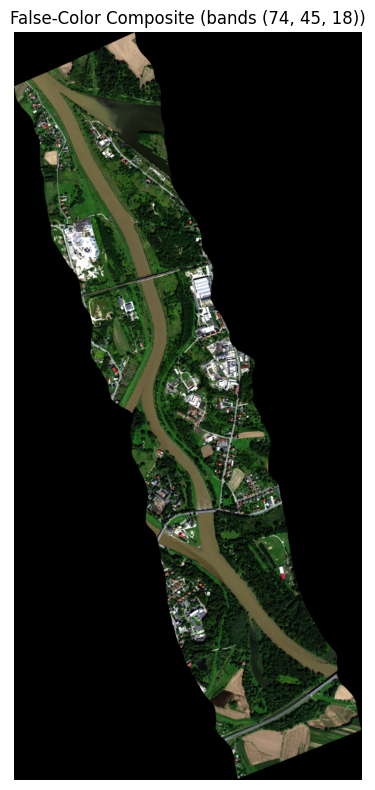

RGB composite shape: (4300, 2001, 3)


In [10]:
# Create a false-color composite (NIR, Red, Green)
# Adjust band indices based on your airborne data
# Example: if bands are sequential and visible + NIR are at the end

# Get default bands from metadata if available
default_bands = meta.get("default bands")
if default_bands:
    rgb_bands = tuple(int(float(b)) - 1 for b in default_bands[:3])
    print(f"Using default bands (0-based): {rgb_bands}")
else:
    # Fallback: use bands toward the end (likely NIR, Red, Green)
    rgb_bands = (airborne_img.nbands - 1, airborne_img.nbands - 20, airborne_img.nbands - 30)
    print(f"Using fallback bands (0-based): {rgb_bands}")

ignore_val = meta.get("data ignore value")
rgb_composite = read_rgb_bands(airborne_img, rgb_bands[0], rgb_bands[1], rgb_bands[2], ignore_value=ignore_val)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(rgb_composite, interpolation="bilinear")
ax.set_title(f"False-Color Composite (bands {rgb_bands})")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"RGB composite shape: {rgb_composite.shape}")

## 3. Water Quality Indices for Airborne Data

Define standard remote sensing indices for water quality assessment.

In [11]:
# Parse wavelengths from metadata
wavelengths = None
if "wavelength" in meta:
    wavelengths = np.array([float(w) for w in meta["wavelength"]])
    print(f"Wavelength range: {wavelengths[0]:.1f} - {wavelengths[-1]:.1f} nm")
    print(f"Number of bands: {len(wavelengths)}")
else:
    print("No wavelength information in metadata.")
    wavelengths = np.arange(airborne_img.nbands)

Wavelength range: 414.1 - 2498.9 nm
Number of bands: 456


In [12]:
def find_band_index(wavelengths, target_wl, tolerance=10):
    """
    Find the band index closest to a target wavelength.
    """
    if wavelengths is None:
        return None
    idx = np.argmin(np.abs(wavelengths - target_wl))
    if np.abs(wavelengths[idx] - target_wl) <= tolerance:
        return idx
    return None

# Identify key bands for water quality indices
band_blue = find_band_index(wavelengths, 490)    # Blue ~490 nm
band_green = find_band_index(wavelengths, 560)   # Green ~560 nm
band_red = find_band_index(wavelengths, 665)     # Red ~665 nm
band_nir = find_band_index(wavelengths, 865)     # NIR ~865 nm

print(f"Identified bands:")
print(f"  Blue (~490 nm): band {band_blue}")
print(f"  Green (~560 nm): band {band_green}")
print(f"  Red (~665 nm): band {band_red}")
print(f"  NIR (~865 nm): band {band_nir}")

Identified bands:
  Blue (~490 nm): band 24
  Green (~560 nm): band 46
  Red (~665 nm): band 78
  NIR (~865 nm): band 141


In [13]:
def compute_ndvi(red, nir):
    """
    Normalized Difference Vegetation Index
    """
    return (nir - red) / (nir + red + 1e-8)

def compute_ndwi(green, nir):
    """
    Normalized Difference Water Index
    """
    return (green - nir) / (green + nir + 1e-8)

def compute_chla_proxy(blue, green):
    """
    Simplified chlorophyll-a proxy (blue-green ratio).
    Higher values may indicate higher biomass.
    """
    return (blue - green) / (blue + green + 1e-8)

def compute_turbidity_proxy(red, nir):
    """
    Simplified turbidity proxy based on red/NIR ratio.
    """
    return red / (nir + 1e-8)

print("Index functions defined.")

Index functions defined.


In [14]:
# Compute indices if required bands are available
indices = {}

if band_red is not None and band_nir is not None:
    red_data = airborne_img.read_band(band_red).astype(np.float32)
    nir_data = airborne_img.read_band(band_nir).astype(np.float32)
    indices["NDVI"] = compute_ndvi(red_data, nir_data)
    print(f"✓ NDVI computed")

if band_green is not None and band_nir is not None:
    green_data = airborne_img.read_band(band_green).astype(np.float32)
    indices["NDWI"] = compute_ndwi(green_data, nir_data)
    print(f"✓ NDWI computed")

if band_blue is not None and band_green is not None:
    blue_data = airborne_img.read_band(band_blue).astype(np.float32)
    indices["Chla_proxy"] = compute_chla_proxy(blue_data, green_data)
    print(f"✓ Chlorophyll-a proxy computed")

if band_red is not None and band_nir is not None:
    indices["Turbidity_proxy"] = compute_turbidity_proxy(red_data, nir_data)
    print(f"✓ Turbidity proxy computed")

print(f"\nComputed indices: {list(indices.keys())}")

✓ NDVI computed
✓ NDWI computed
✓ Chlorophyll-a proxy computed
✓ Turbidity proxy computed

Computed indices: ['NDVI', 'NDWI', 'Chla_proxy', 'Turbidity_proxy']


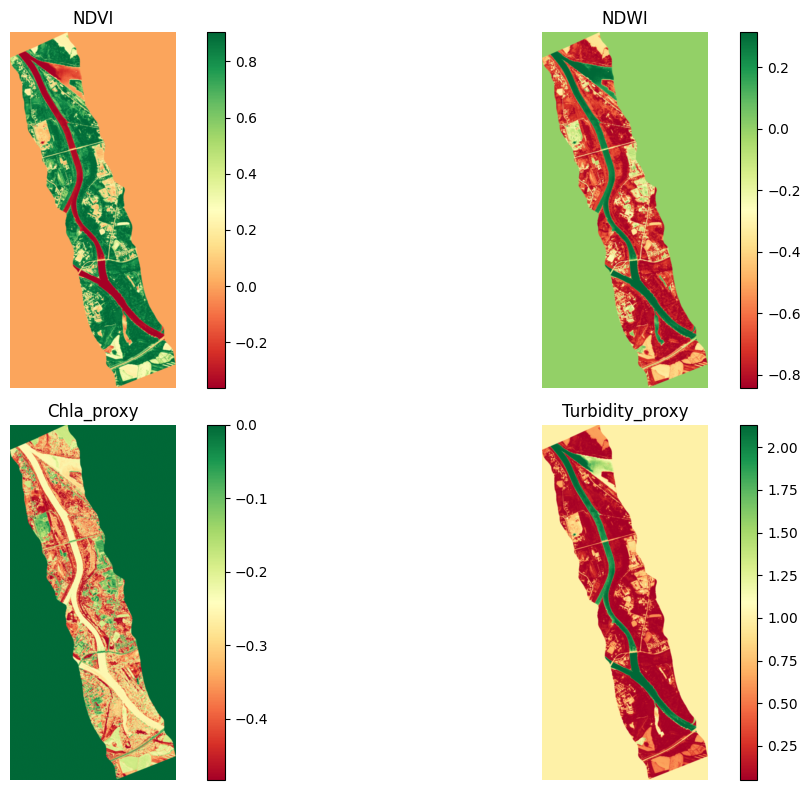

In [15]:
# Visualize computed indices
if indices:
    ncols = min(2, len(indices))
    nrows = (len(indices) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (name, data) in enumerate(indices.items()):
        ax = axes[idx]
        vmin, vmax = np.nanpercentile(data, [2, 98])
        im = ax.imshow(data, cmap="RdYlGn", vmin=vmin, vmax=vmax, interpolation="bilinear")
        ax.set_title(f"{name}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    for idx in range(len(indices), len(axes)):
        axes[idx].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("No indices computed. Check band identification.")

## 4. Download Sentinel-2 Data

Search for Sentinel-2 scenes temporally close to the airborne acquisition.

In [ ]:
# TODO: Set acquisition date and AOI for the airborne data
# Placeholder values - update based on your actual data

AIRBORNE_ACQUISITION_DATE = "2024-06-01"  # Example date
AOI_BOUNDS = None  # Update with (minx, miny, maxx, maxy) or a GeoJSON polygon

print(f"Target acquisition date: {AIRBORNE_ACQUISITION_DATE}")
print(f"AOI: {AOI_BOUNDS}")
print(f"\nNote: Implement search using pystac-client or planetary-computer API")

In [ ]:
# Example placeholder for Sentinel-2 search (requires pystac-client)
# Uncomment and adapt when pystac-client is installed

# from pystac_client import Client
# from datetime import datetime, timedelta
#
# # Search for Sentinel-2 L2A data
# catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
# search_date = datetime.fromisoformat(AIRBORNE_ACQUISITION_DATE)
# date_range = f"{(search_date - timedelta(days=5)).isoformat()}/{(search_date + timedelta(days=5)).isoformat()}"
#
# search = catalog.search(
#     query=[
#         {"collection": {"eq": "sentinel-2-l2a"}},
#         {"eo:cloud_cover": {"lt": 20}},
#     ],
#     datetime=date_range,
#     bbox=AOI_BOUNDS,
# )
#
# items = list(search.get_items())
# print(f"Found {len(items)} Sentinel-2 scenes")

print("Sentinel-2 search placeholder. Implement with pystac-client when data bounds are known.")

## 5. Sentinel-2 Indices

Compute the same indices for Sentinel-2 data and compare with airborne.

In [ ]:
# TODO: Load downloaded Sentinel-2 data (multi-spectral, limited to 12 bands)
# Apply the same index functions to Sentinel-2 bands
# Compare the results spatially and statistically

print("Sentinel-2 processing placeholder. Awaiting data download.")
print("\nExpected workflow:")
print("  1. Load Sentinel-2 B2 (blue), B3 (green), B4 (red), B8 (NIR)")
print("  2. Resample to common grid if needed")
print("  3. Apply same index functions")
print("  4. Create comparison plots")

## 6. Comparison: Airborne vs. Sentinel-2

In [ ]:
# TODO: If both datasets are available, create comparison plots
# - Side-by-side index maps
# - Scatter plots of pixel values
# - Correlation analysis
# - Difference maps

print("Comparison analysis placeholder.")
print("\nTo be implemented after Sentinel-2 data is processed.")

## 7. Spectral Library and SAM

Load the spectral library from Lab 3 and implement Spectral Angle Mapper.

In [ ]:
# TODO: Load spectral library from Lab 3
# Expected format: CSV with wavelengths and reference spectra for:
# - Water
# - Green areas / vegetation
# - Forest
# - Other land covers

spectral_lib_path = SPECTRAL_LIB_DIR / "spectral_samples.csv"
if spectral_lib_path.exists():
    spectral_lib = pd.read_csv(spectral_lib_path)
    print(f"Loaded spectral library: {spectral_lib.shape}")
    print(spectral_lib.head())
else:
    print(f"Spectral library not found at {spectral_lib_path}")
    print("Create reference spectra in Lab 3 first.")

In [ ]:
def spectral_angle(reference, target):
    """
    Compute spectral angle (in degrees) between two spectra.
    Lower angles indicate higher similarity.
    """
    # Normalize vectors
    ref_norm = np.linalg.norm(reference)
    tgt_norm = np.linalg.norm(target)
    if ref_norm == 0 or tgt_norm == 0:
        return np.nan
    
    ref_normalized = reference / ref_norm
    tgt_normalized = target / tgt_norm
    
    # Compute angle
    dot_product = np.clip(np.dot(ref_normalized, tgt_normalized), -1, 1)
    angle_rad = np.arccos(dot_product)
    angle_deg = np.degrees(angle_rad)
    return angle_deg

print("SAM function defined.")

In [ ]:
# TODO: Implement SAM classification
# For each pixel spectrum in the airborne cube:
# - Compute spectral angle to each reference spectrum
# - Assign class based on minimum angle
# - Optional: Use airborne data for calibration/refinement of references

print("SAM classification placeholder.")
print("\nExpected outputs:")
print("  - Classification map (land cover class per pixel)")
print("  - Angle map (minimum spectral angle per pixel)")
print("  - Confidence / statistics")

## 8. Calibration Considerations

Discuss and implement calibration strategies using airborne data to refine Sentinel-2 results.

In [ ]:
# Calibration strategies:
# 1. Direct calibration: Use airborne reference spectra as ground truth for Sentinel-2 indices
# 2. Virtual ground stations: Sample airborne spectra at known locations and use for S2 validation
# 3. Cross-sensor empirical relationship: Fit polynomial or linear model between indices

calibration_notes = """
Calibration Approach:
- The airborne data has higher spatial and spectral resolution.
- Use airborne-derived indices or classifications as validation reference.
- Sentinel-2 is widely available but lower resolution (10-20m).
- Strategy: If airborne and S2 cover same area on same date,
  use airborne to recalibrate S2 indices or expand S2 maps.
"""
print(calibration_notes)

## 9. Summary and Conclusions

In [ ]:
summary = f"""
Lab 5 Summary:
=============

1. Airborne Data Explored:
   - File: {airborne_path.name if 'airborne_path' in locals() else 'N/A'}
   - Indices computed: {list(indices.keys()) if 'indices' in locals() else 'None'}

2. False-Color Composites: Generated

3. Water Quality Indices:
   - NDVI, NDWI: Computed if bands available
   - Chl-a proxy, Turbidity proxy: Computed

4. Sentinel-2 Data: (Implement when available)
   - Search and download
   - Index alignment

5. SAM Classification: (Implement after spectral library ready)
   - Classify pixels using Lab 3 reference spectra
   - Generate classification maps

6. Calibration: Consider airborne data as calibration source for Sentinel-2.
"""
print(summary)